In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import our custom EDA functions
from eda_functions import *

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


# 2. Load dataset

In [4]:
# Load the data
df = load_data("../data/raw/default_of_credit_card_clients.csv", clean_cols=True, drop_unnamed=True)
df = df.rename(columns={'default payment next month': 'Class'})

if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# Preview
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Class
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# 3. Basic Overview

In [5]:
overview(df)

===== DATASET OVERVIEW =====
Shape: 30000 rows, 24 columns

Data Types:
 LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
Class        int64
dtype: object 

Missing Values:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
Class        0
dtype: int64 

Summary Statistics:
             LIMIT_BAL           SEX     ED

# 4. Feature Descriptions

In [6]:
column_descriptions = {
    'LIMIT_BAL': 'Credit Limit (NT$)',
    'SEX': 'Gender (1=Male, 2=Female)',
    'EDUCATION': 'Education Level',
    'MARRIAGE': 'Marital Status',
    'AGE': 'Age (years)',
    'PAY_0': 'Repayment Status Sep',
    'PAY_2': 'Repayment Status Aug',
    'PAY_3': 'Repayment Status Jul',
    'PAY_4': 'Repayment Status Jun',
    'PAY_5': 'Repayment Status May',
    'PAY_6': 'Repayment Status Apr',
    'BILL_AMT1': 'Bill Amount Sep',
    'BILL_AMT2': 'Bill Amount Aug',
    'BILL_AMT3': 'Bill Amount Jul',
    'BILL_AMT4': 'Bill Amount Jun',
    'BILL_AMT5': 'Bill Amount May',
    'BILL_AMT6': 'Bill Amount Apr',
    'PAY_AMT1': 'Payment Amount Sep',
    'PAY_AMT2': 'Payment Amount Aug',
    'PAY_AMT3': 'Payment Amount Jul',
    'PAY_AMT4': 'Payment Amount Jun',
    'PAY_AMT5': 'Payment Amount May',
    'PAY_AMT6': 'Payment Amount Apr',
}

print("Feature descriptions:")
for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"  {col:15s}: {desc}")


Feature descriptions:
  LIMIT_BAL      : Credit Limit (NT$)
  SEX            : Gender (1=Male, 2=Female)
  EDUCATION      : Education Level
  MARRIAGE       : Marital Status
  AGE            : Age (years)
  PAY_0          : Repayment Status Sep
  PAY_2          : Repayment Status Aug
  PAY_3          : Repayment Status Jul
  PAY_4          : Repayment Status Jun
  PAY_5          : Repayment Status May
  PAY_6          : Repayment Status Apr
  BILL_AMT1      : Bill Amount Sep
  BILL_AMT2      : Bill Amount Aug
  BILL_AMT3      : Bill Amount Jul
  BILL_AMT4      : Bill Amount Jun
  BILL_AMT5      : Bill Amount May
  BILL_AMT6      : Bill Amount Apr
  PAY_AMT1       : Payment Amount Sep
  PAY_AMT2       : Payment Amount Aug
  PAY_AMT3       : Payment Amount Jul
  PAY_AMT4       : Payment Amount Jun
  PAY_AMT5       : Payment Amount May
  PAY_AMT6       : Payment Amount Apr


## 5. Target Variable Distribution

===== TARGET DISTRIBUTION =====
Class
0    23364
1     6636
Name: count, dtype: int64

Imbalance Ratio: 3.52:1
Default Rate: 22.12%


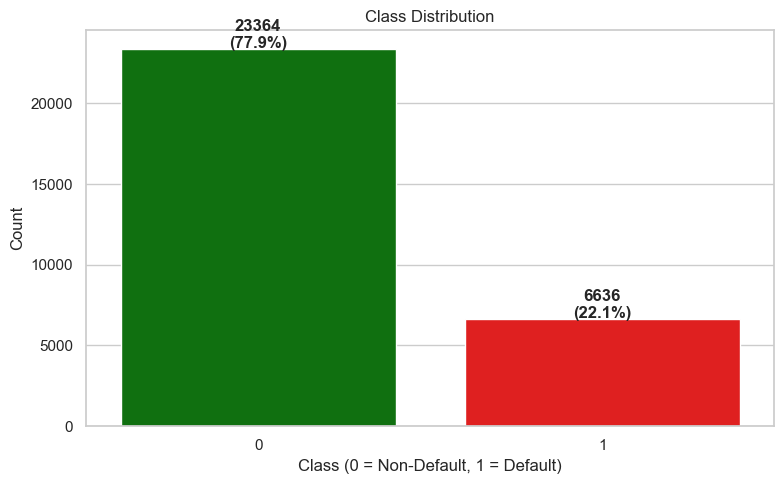

In [7]:
plot_target_distribution(
    df, 
    target_col='Class',
    save_path='../figures/default_credit_class_distribution.png'
)

# 6. Feature Types

In [8]:
num_cols, cat_cols = get_feature_types(df, target='Class')
print("Numerical features:", num_cols)
print("Categorical features:", cat_cols if cat_cols else "None")

Numerical features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical features: None


# 7. Numerical Feature Analysis
## Descriptive Statistics

In [9]:
range_df = df[num_cols].agg(['min', 'max']).T
range_df.columns = ['Min', 'Max']
range_dfrange_df = df[num_cols].agg(['min', 'max']).T
range_df.columns = ['Min', 'Max']
range_df

range_df['Range'] = range_df['Max'] - range_df['Min']
range_df

,Min,Max,Range
LIMIT_BAL,10000,1000000,990000
SEX,1,2,1
EDUCATION,0,6,6
MARRIAGE,0,3,3
AGE,21,79,58
PAY_0,-2,8,10
PAY_2,-2,8,10
PAY_3,-2,8,10
PAY_4,-2,8,10
PAY_5,-2,8,10


## Histograms

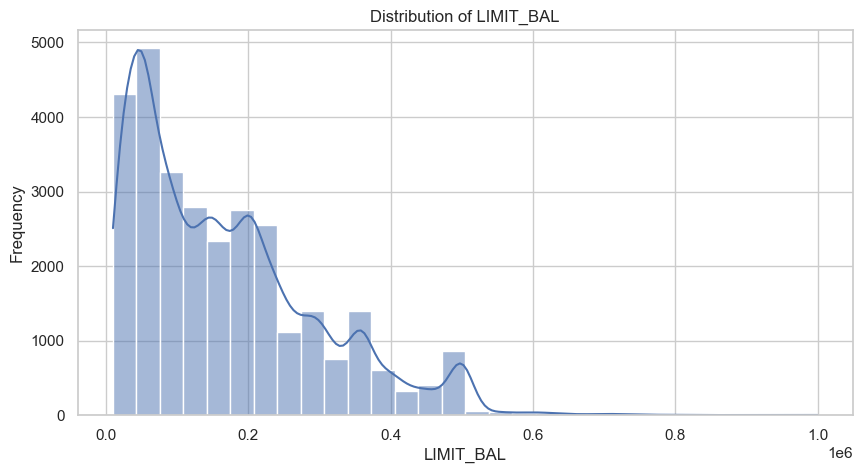

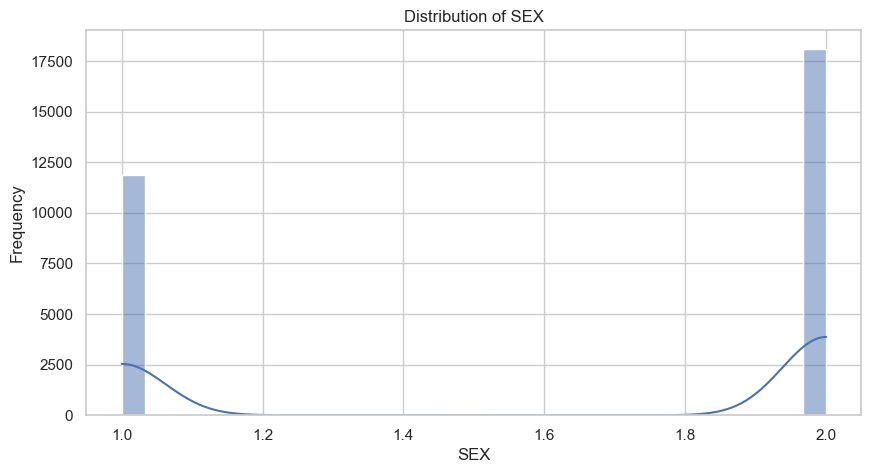

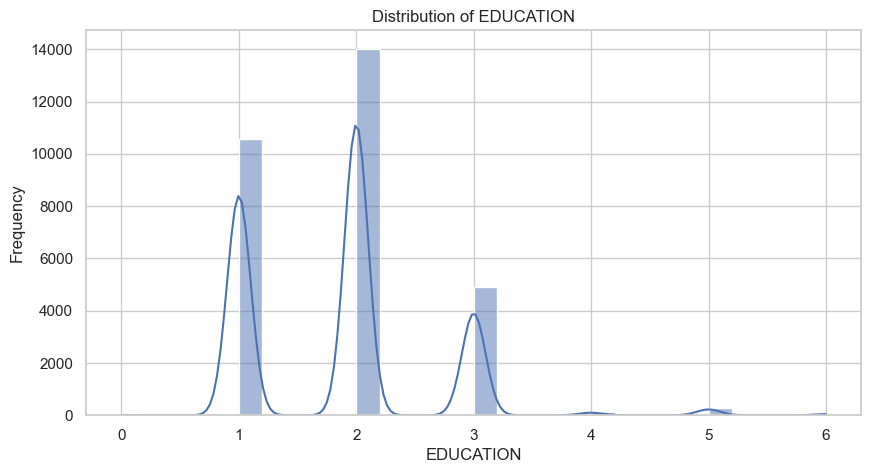

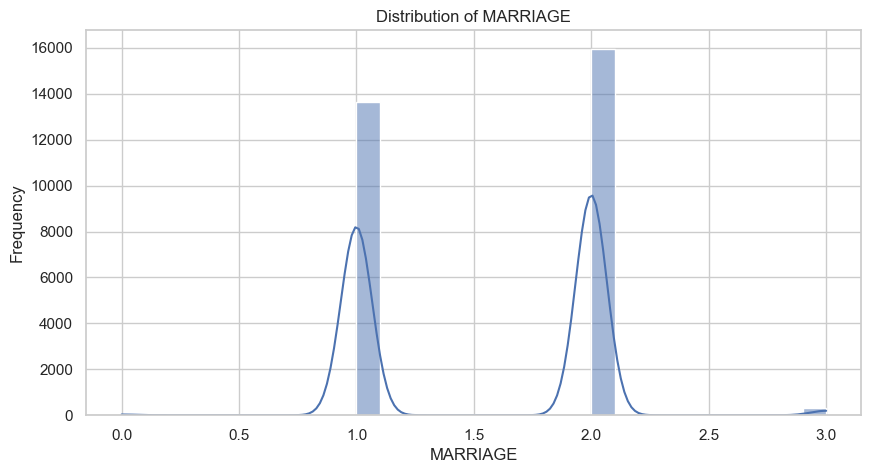

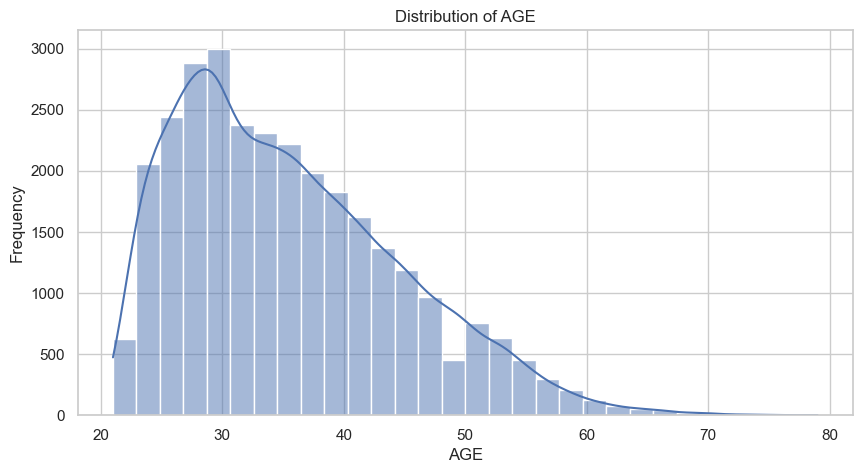

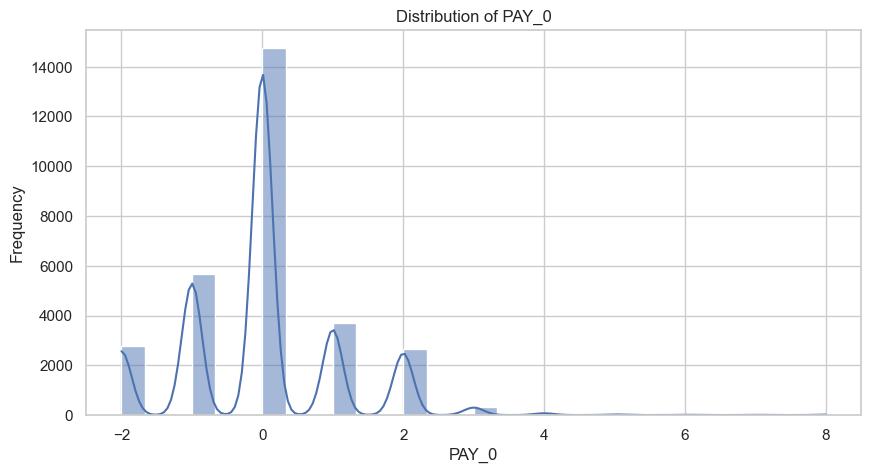

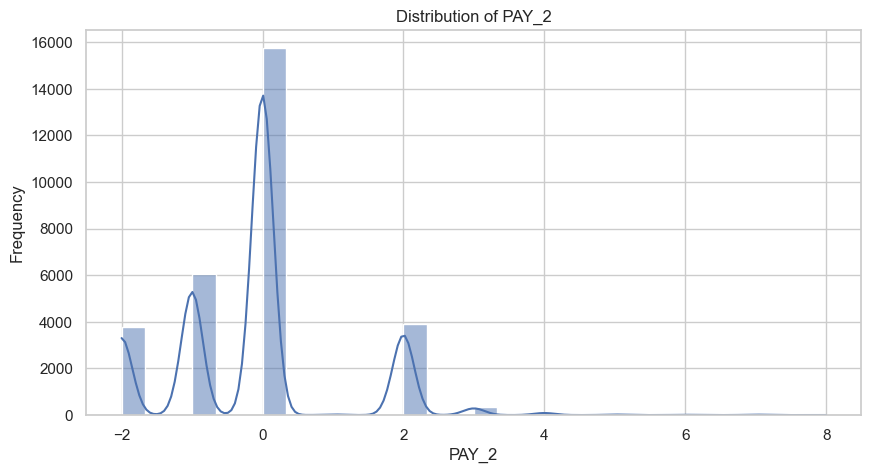

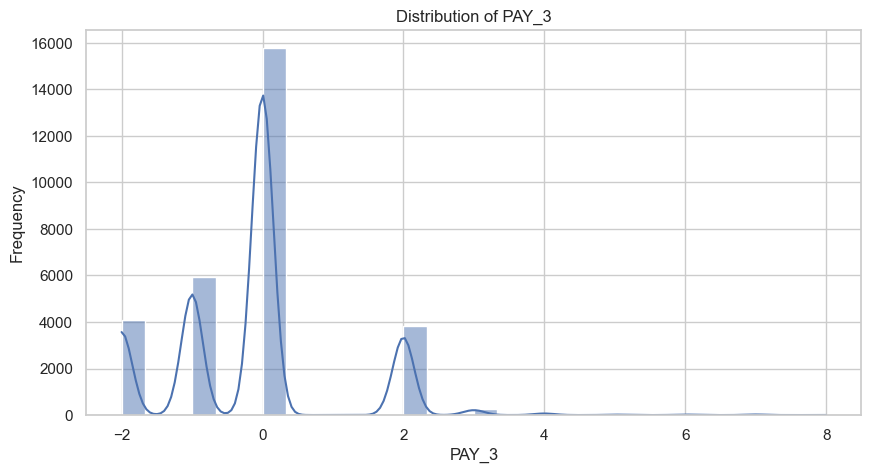

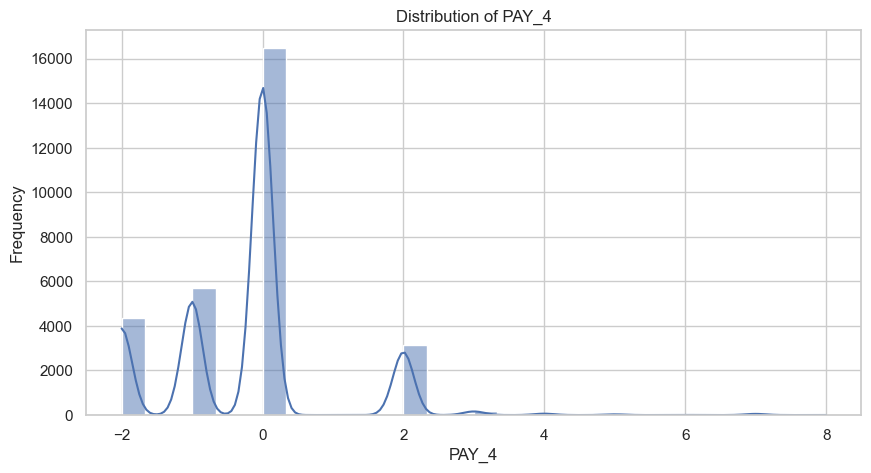

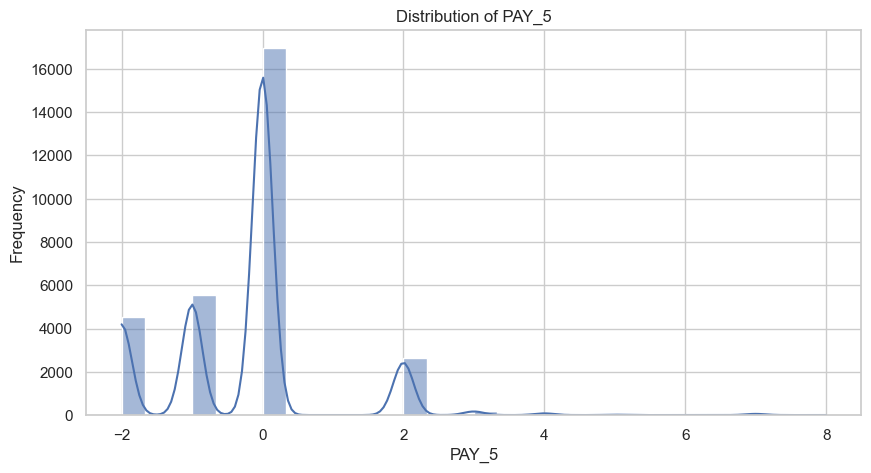

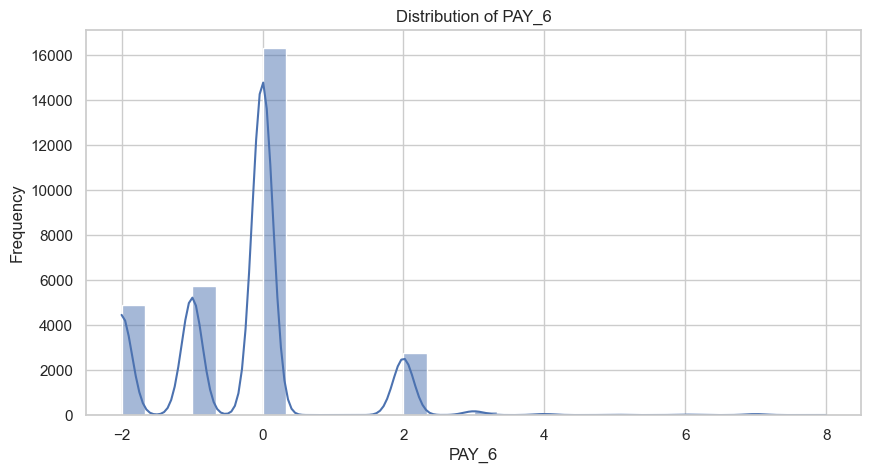

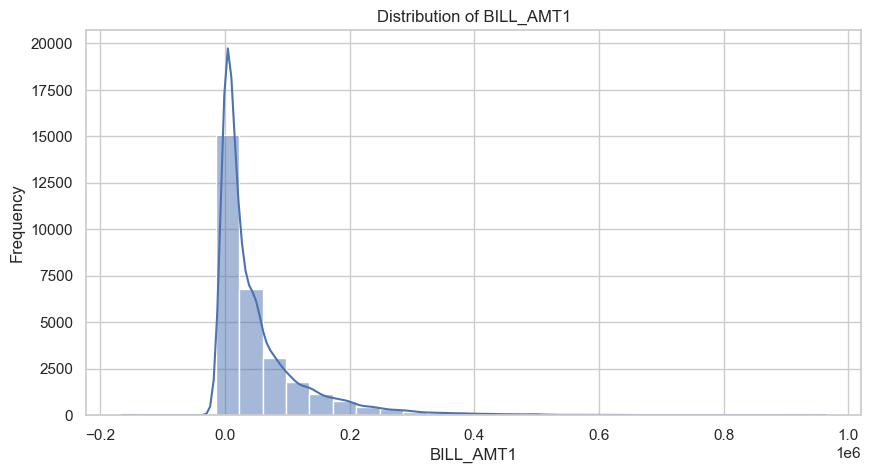

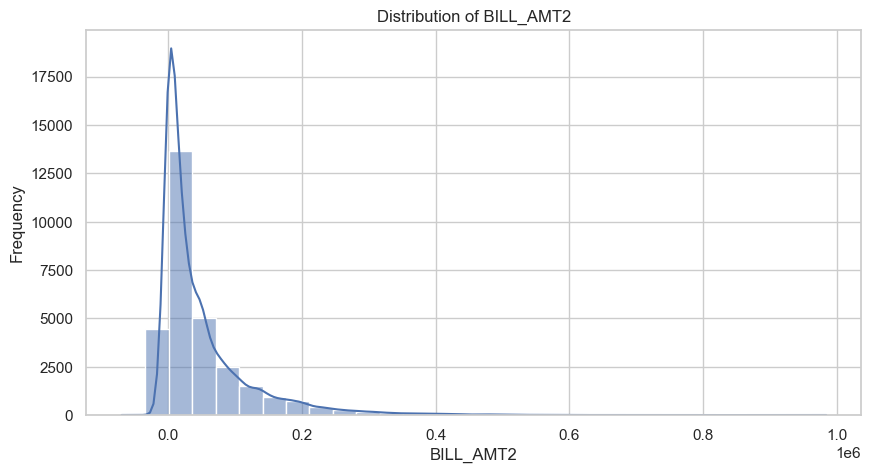

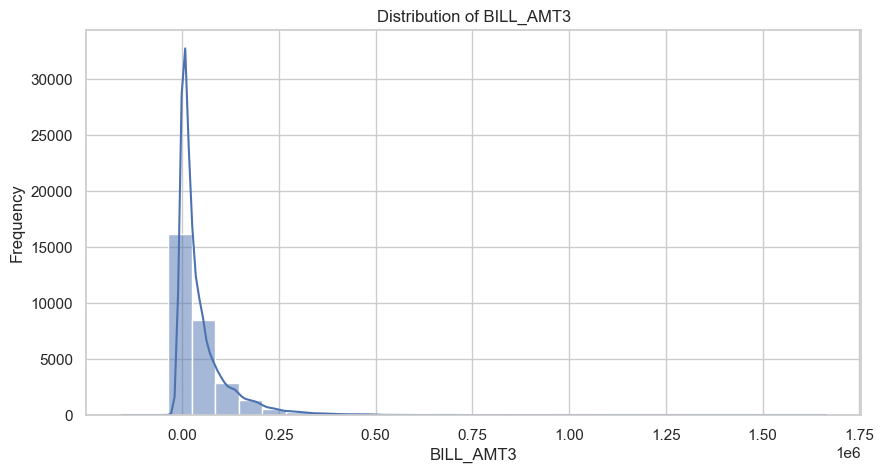

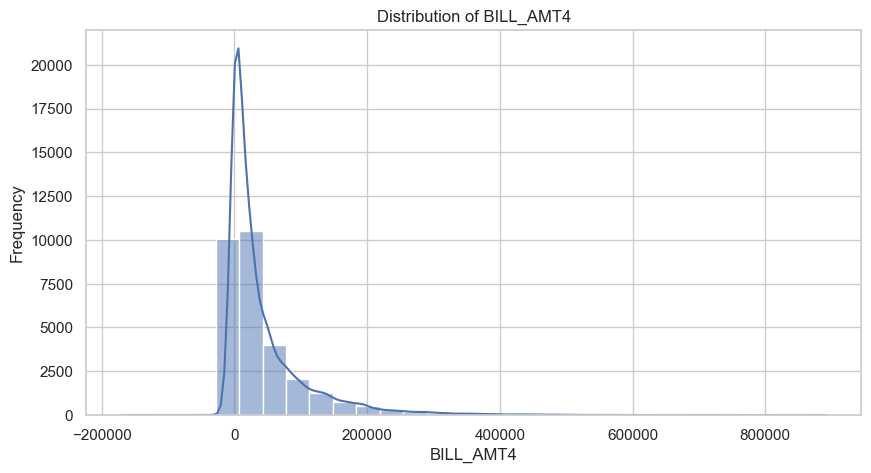

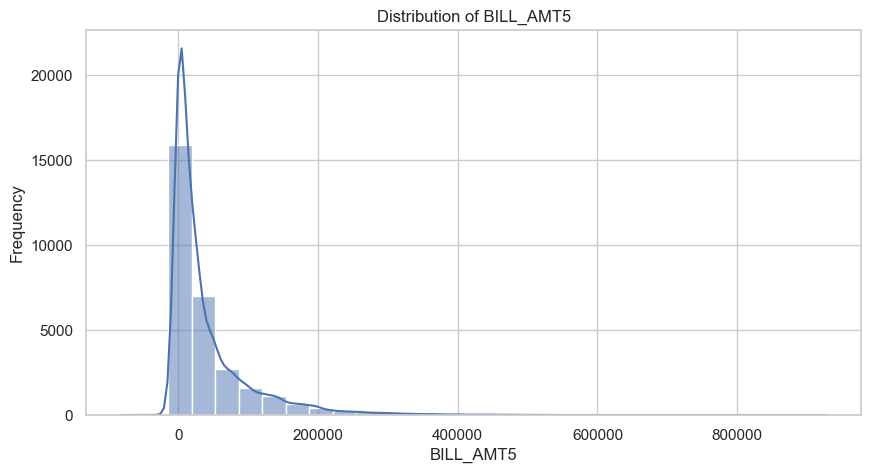

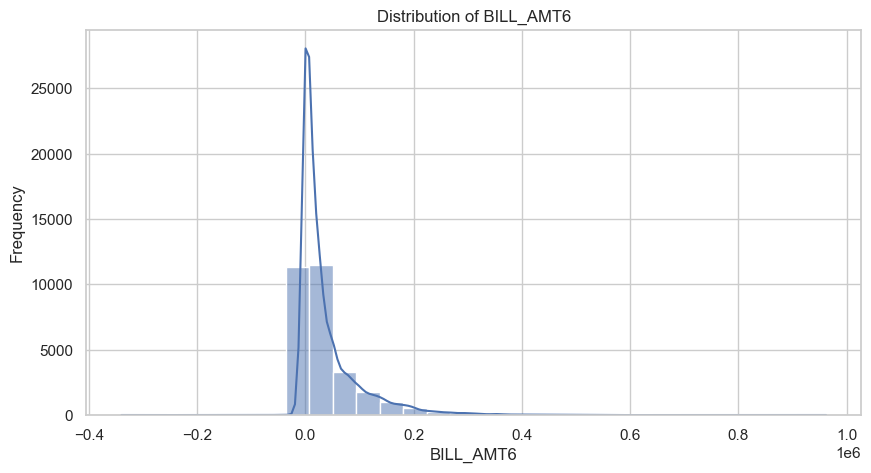

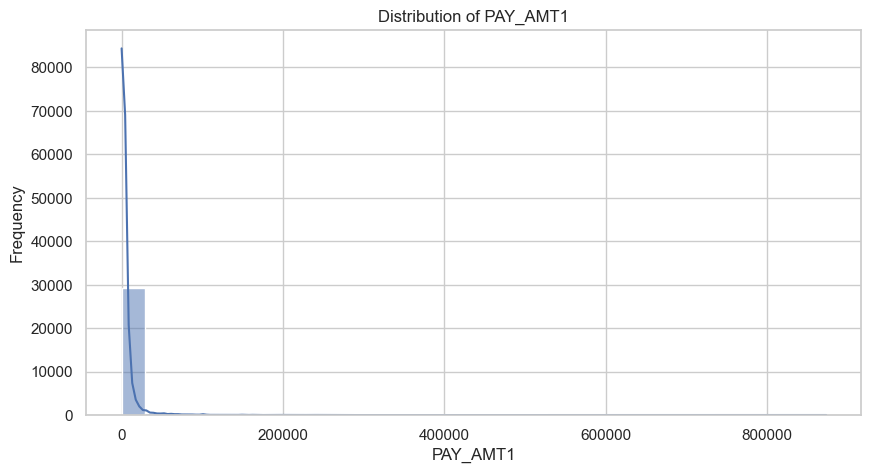

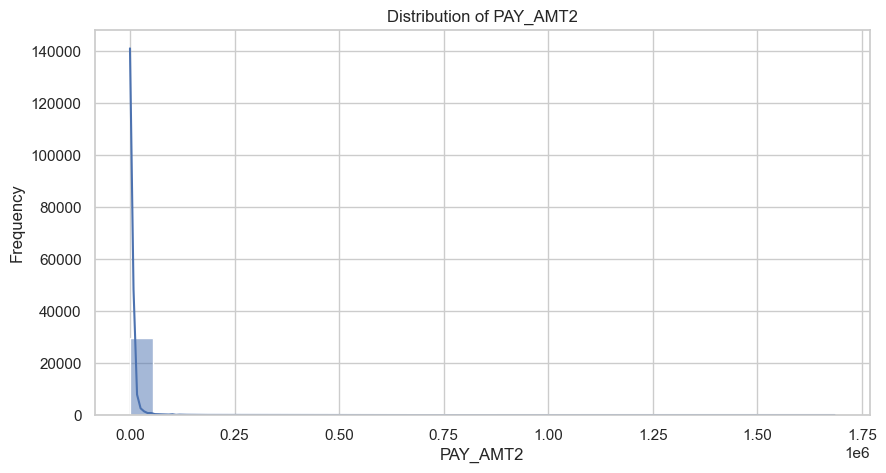

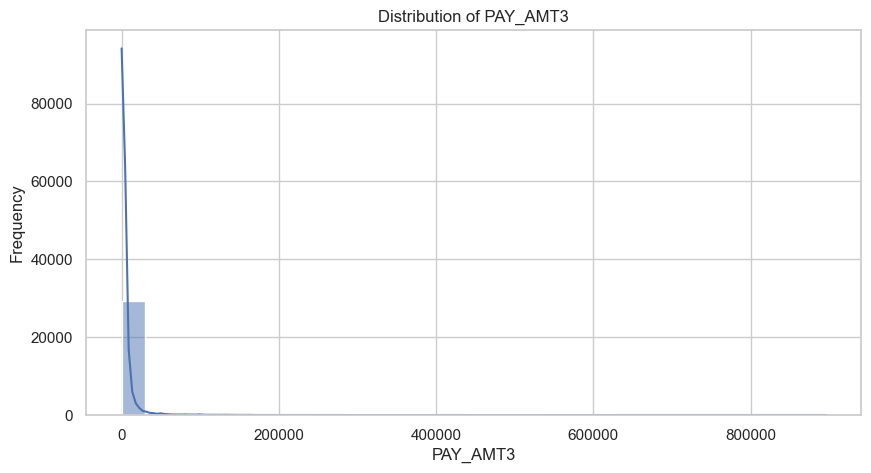

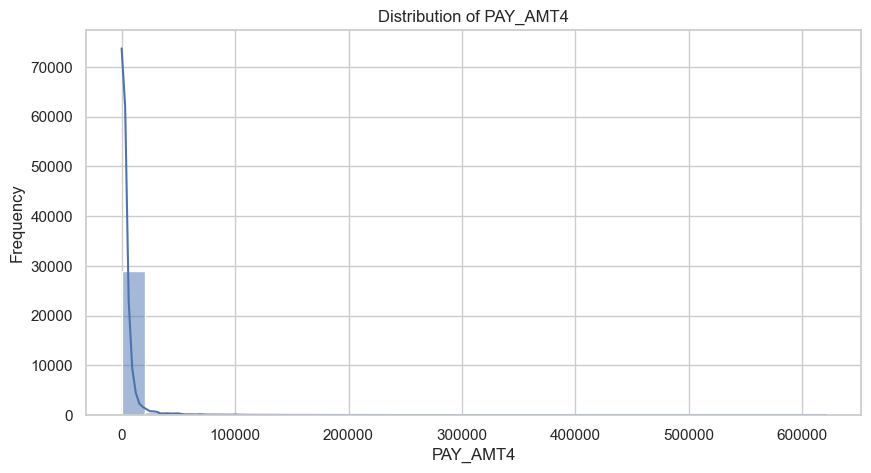

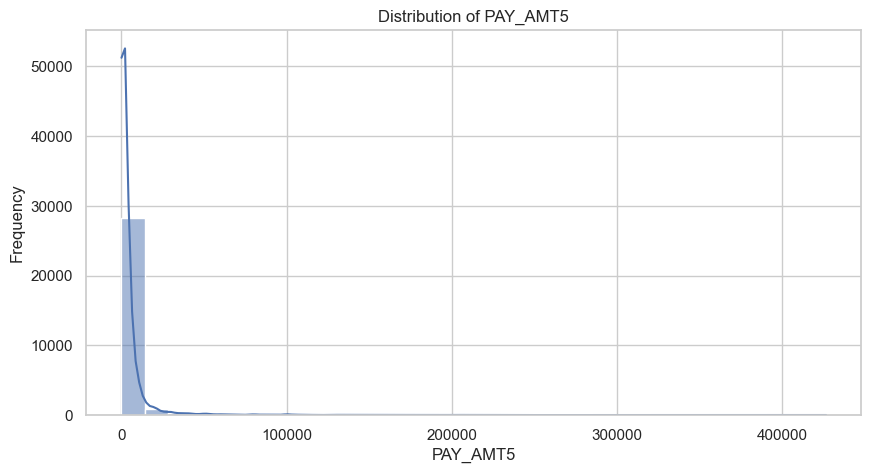

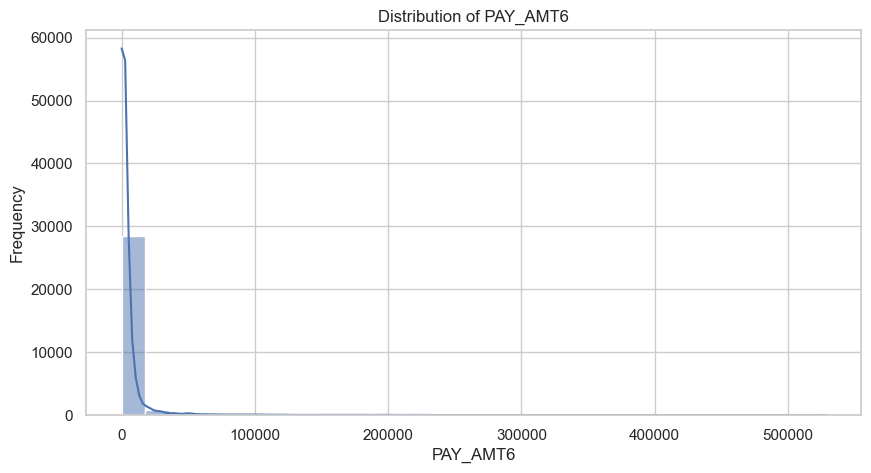

In [10]:
# Histograms with KDE
plot_numerical(df, cols=num_cols, kde=True)

## Boxplots (Outlier Detection)

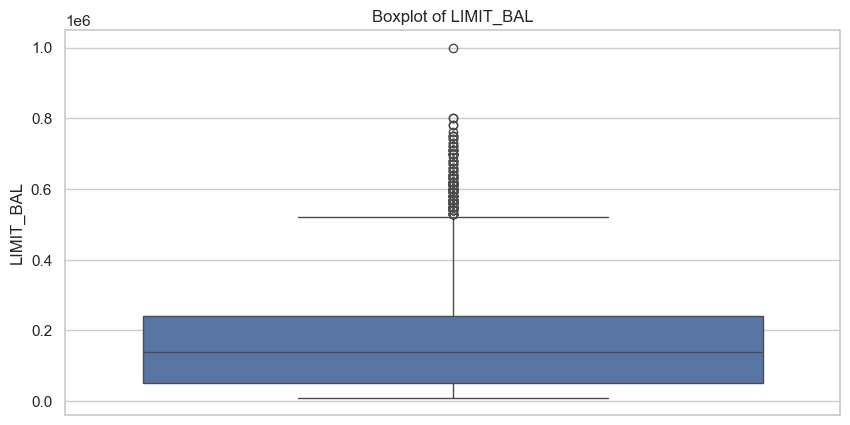

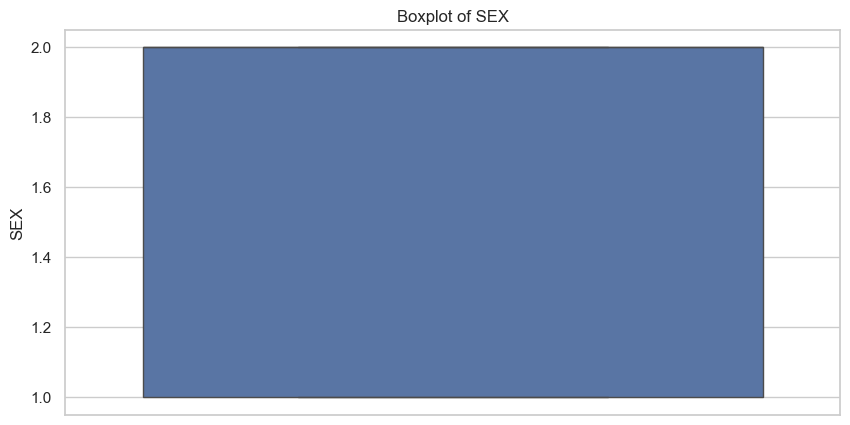

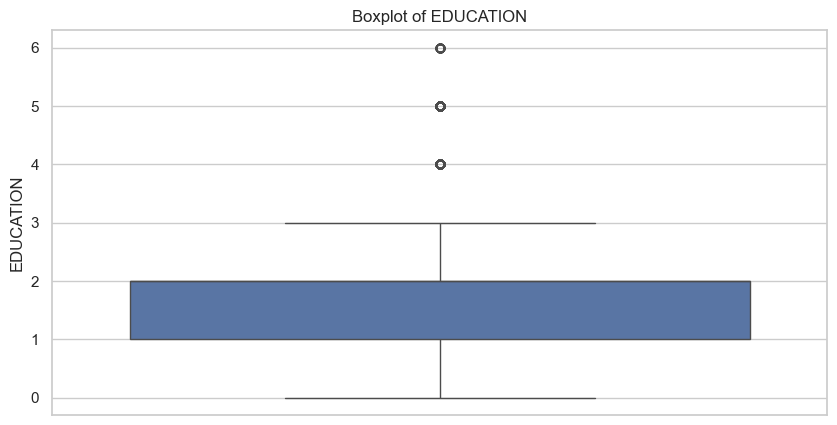

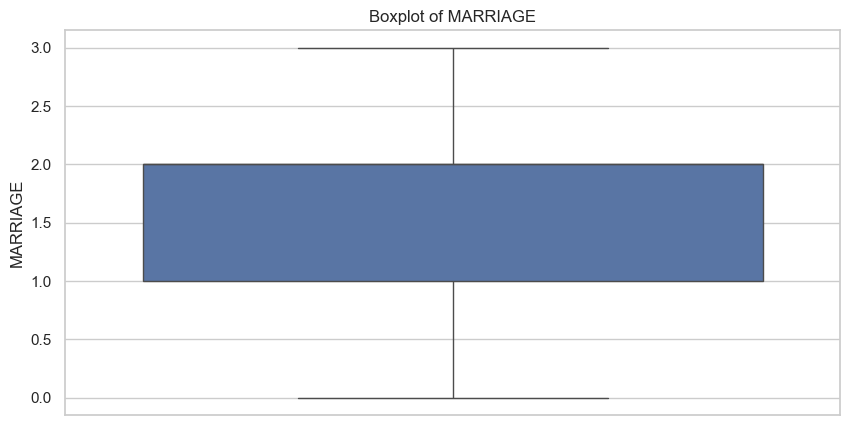

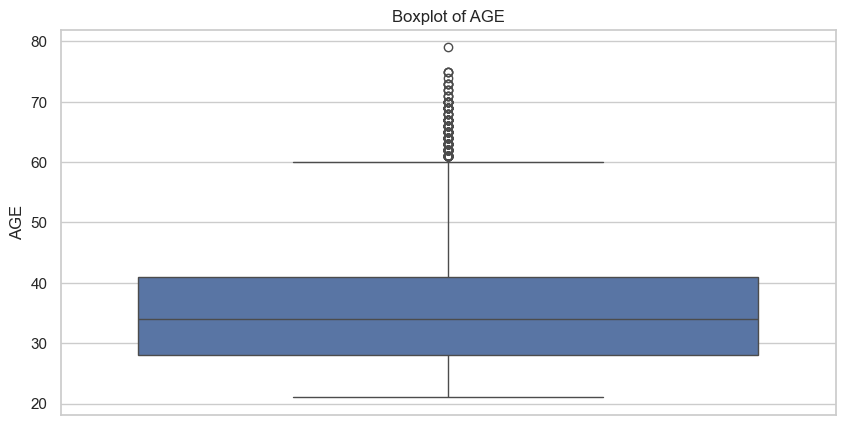

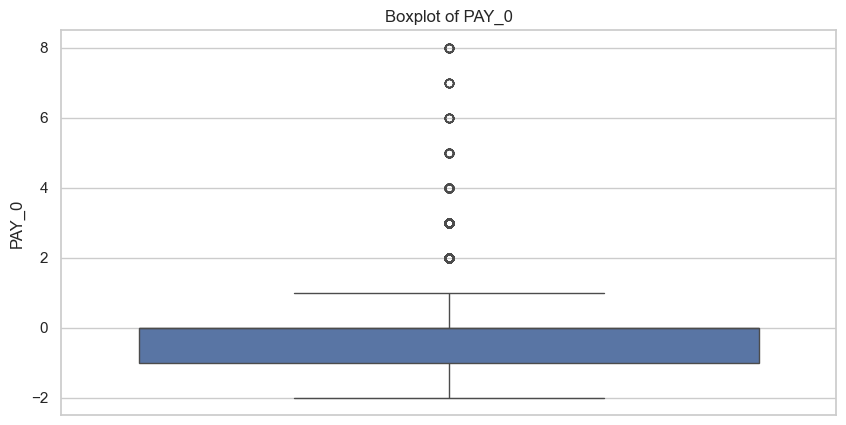

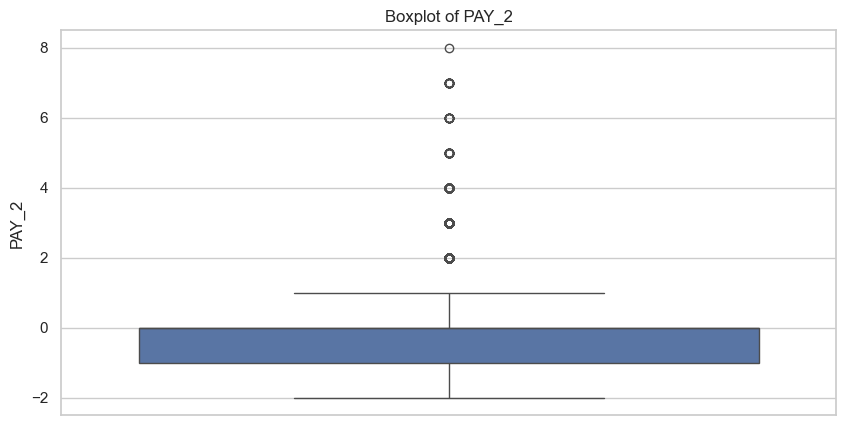

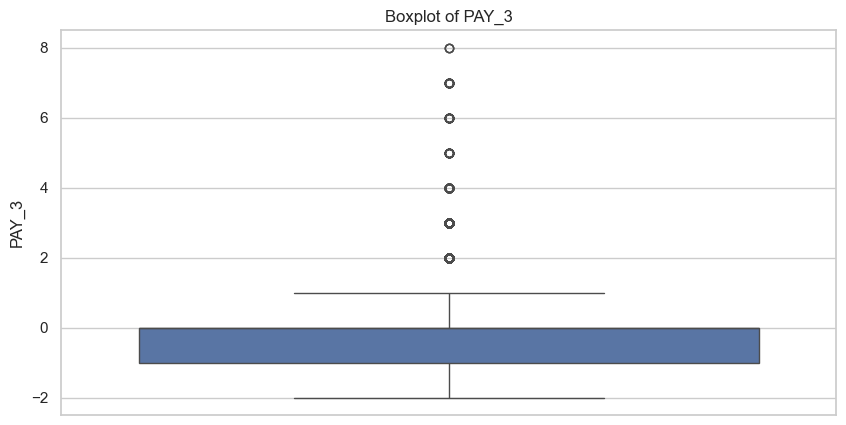

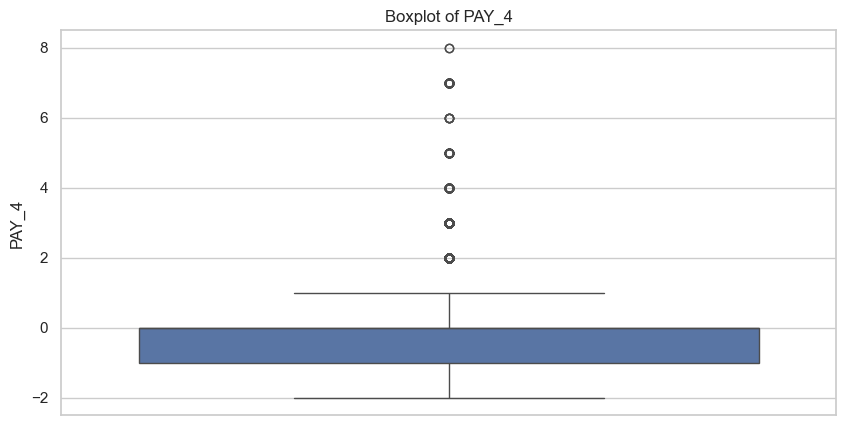

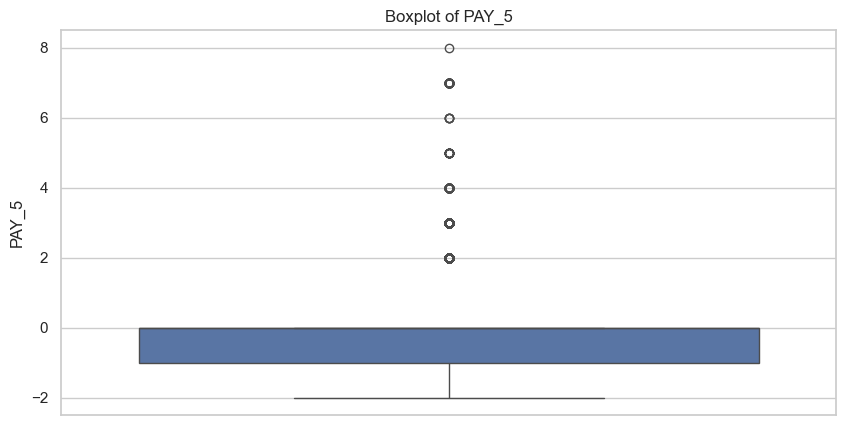

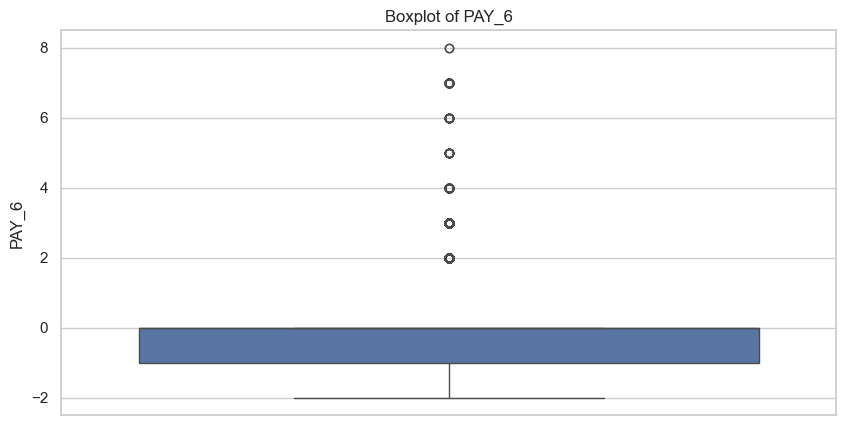

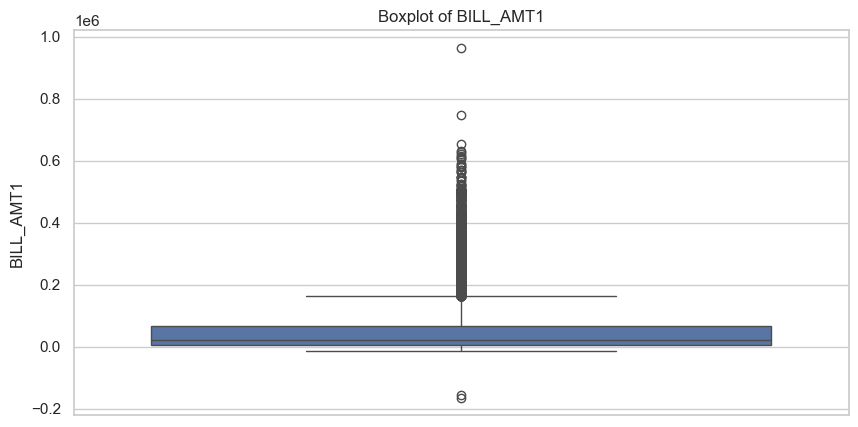

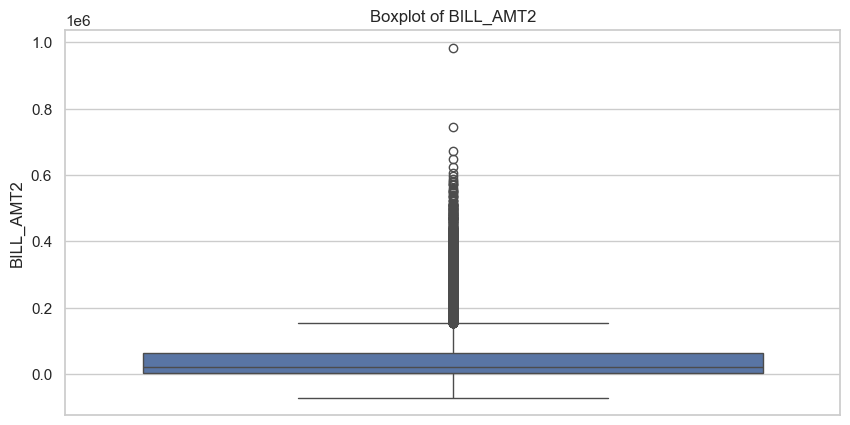

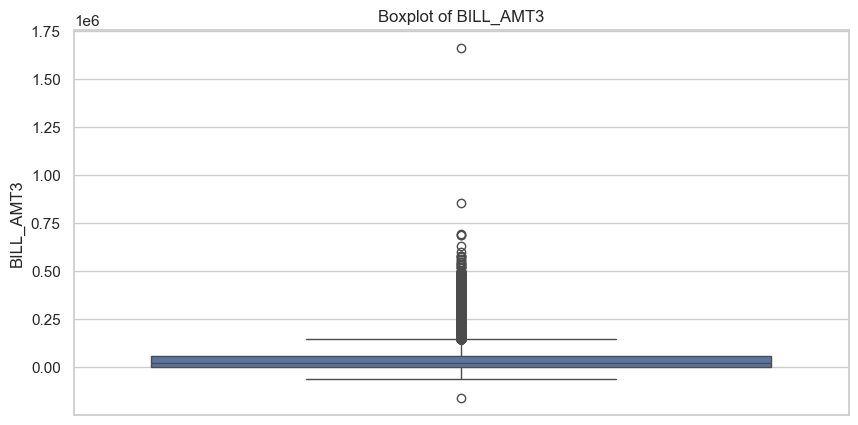

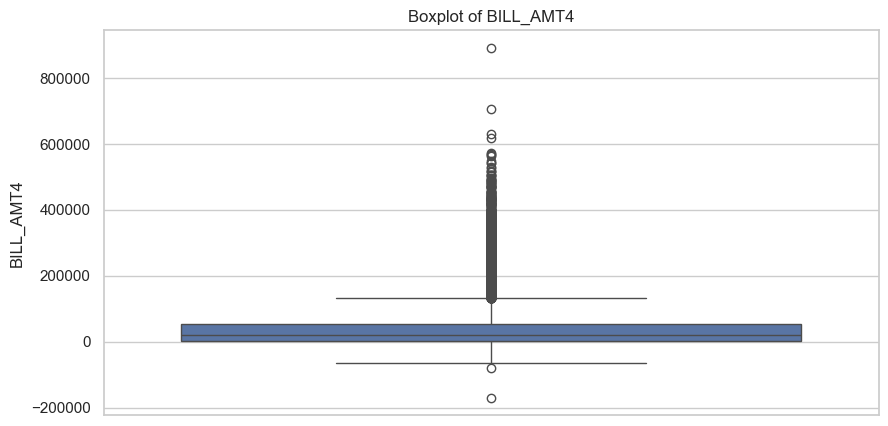

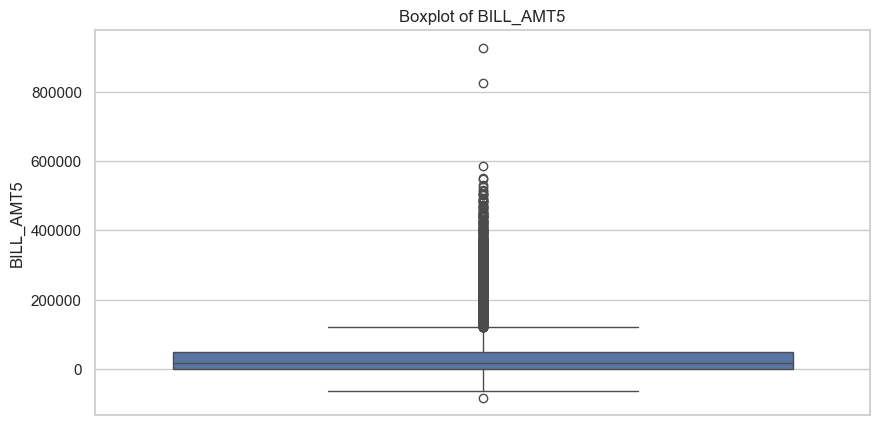

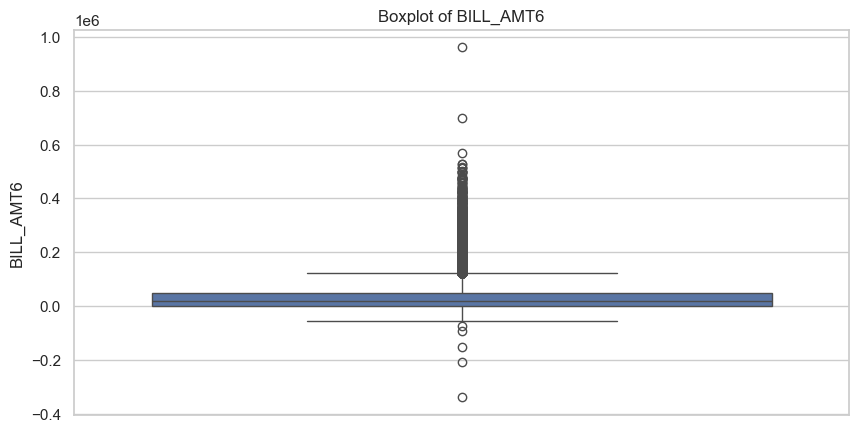

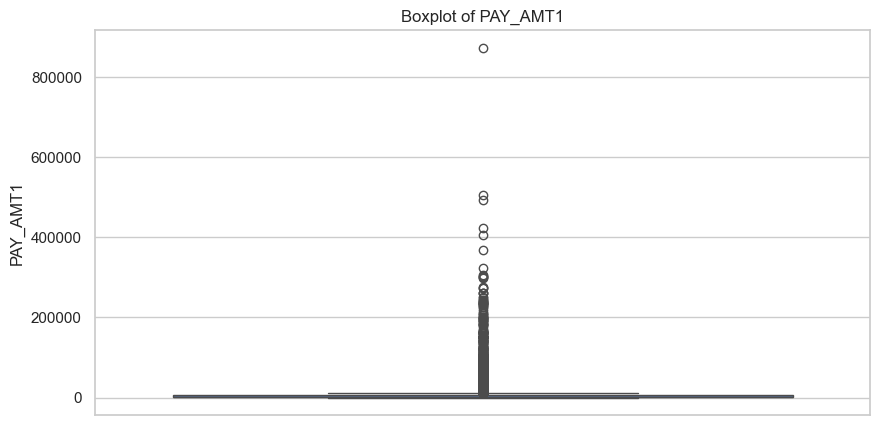

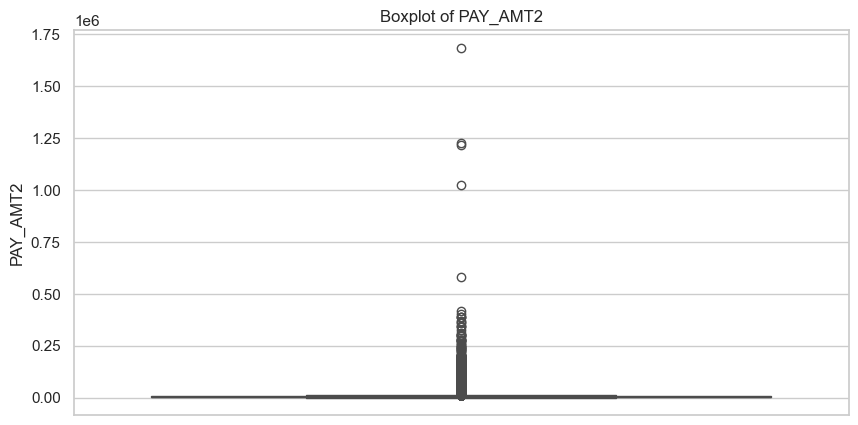

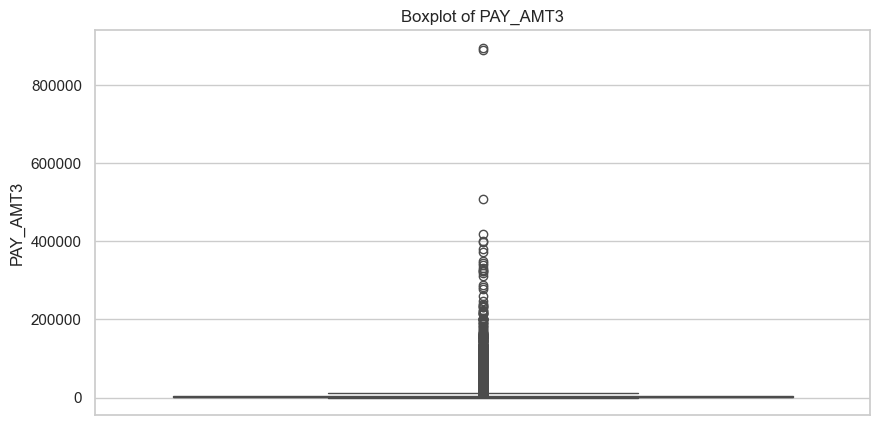

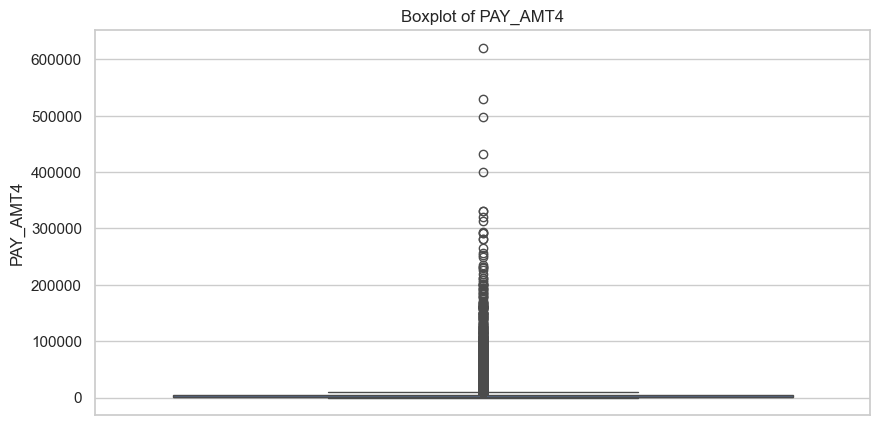

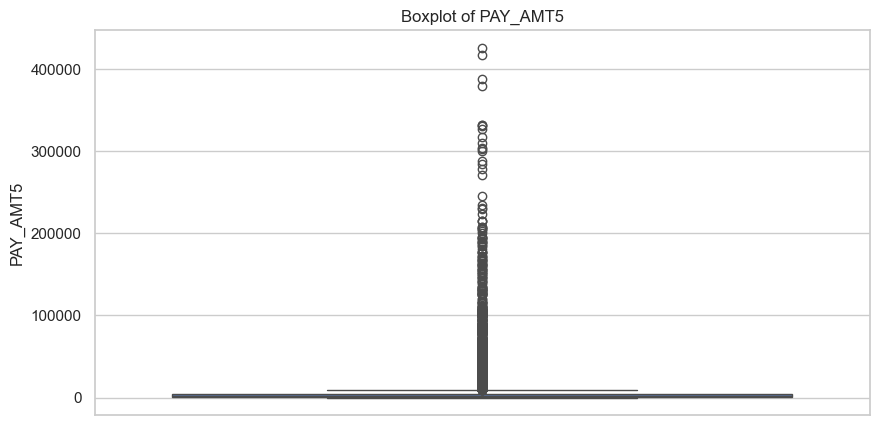

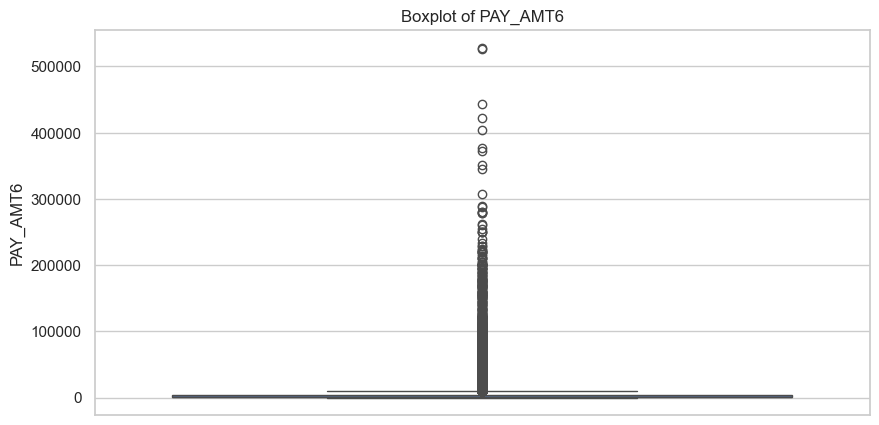

In [11]:
# Boxplots for outlier visualization
plot_outliers_boxplot(df, cols=num_cols)

# 8. Categorical Feature Analysis
##  Value Counts

In [12]:
# Value counts for each categorical feature
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())

# 9. Bivariate Analysis (Feature vs Target)
## Categorical vs Target

In [13]:
# Categorical vs target
plot_cat_vs_target(df, cat_cols, target='Class')

## Numerical vs Target

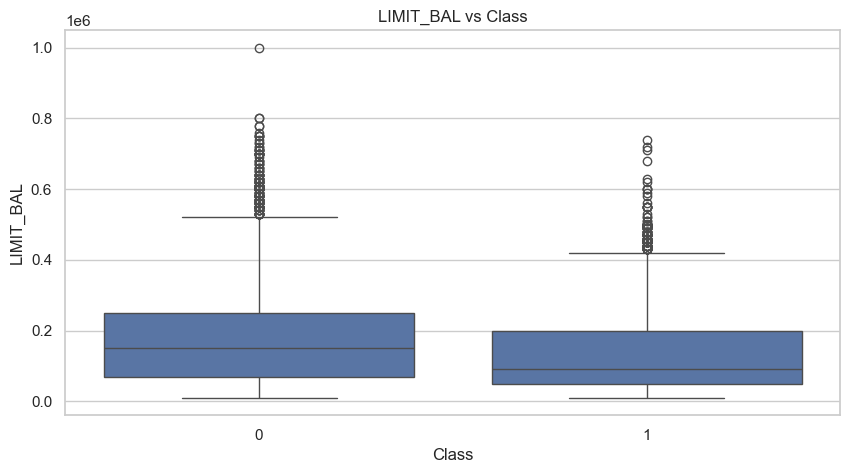

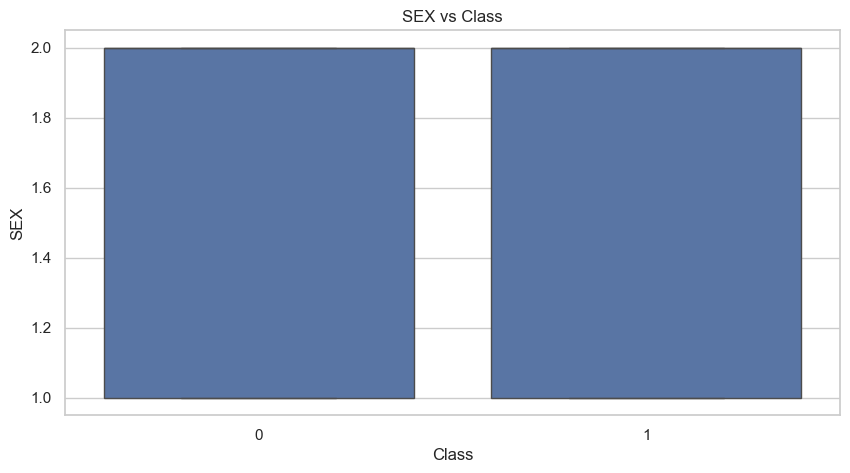

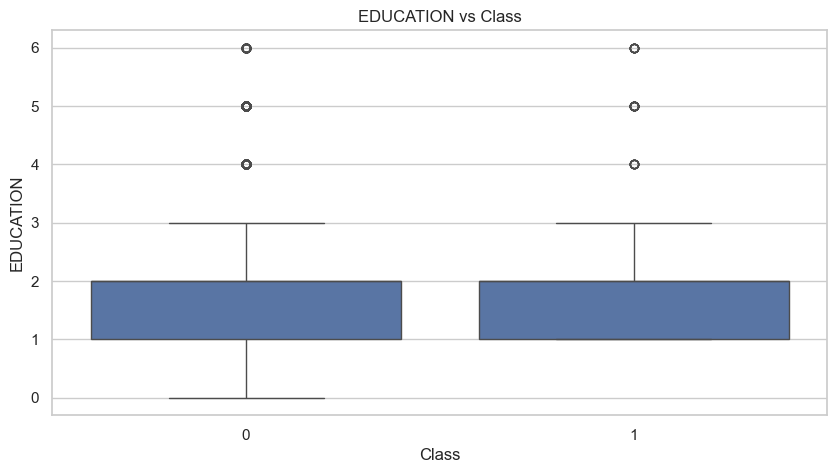

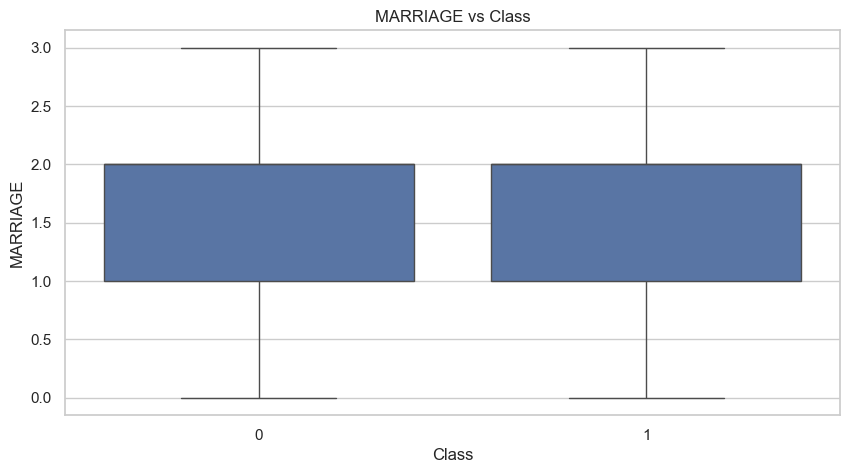

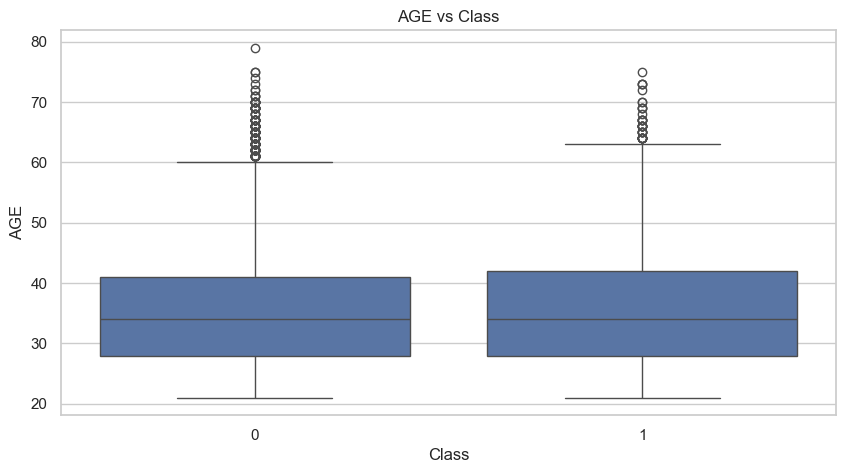

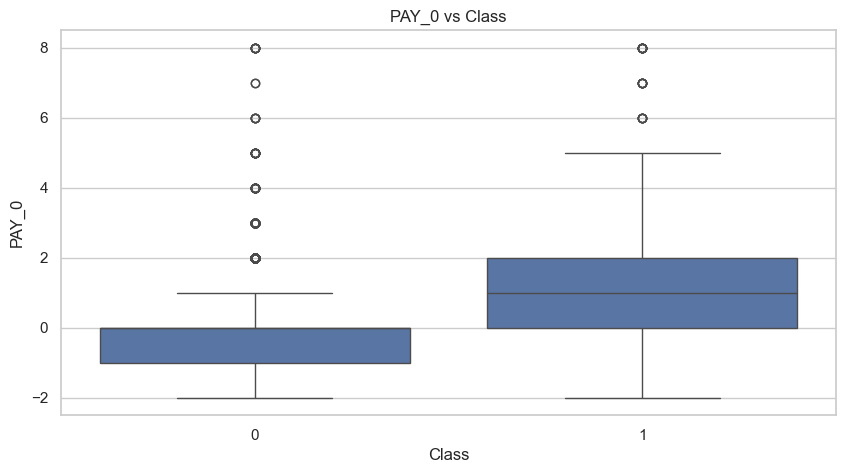

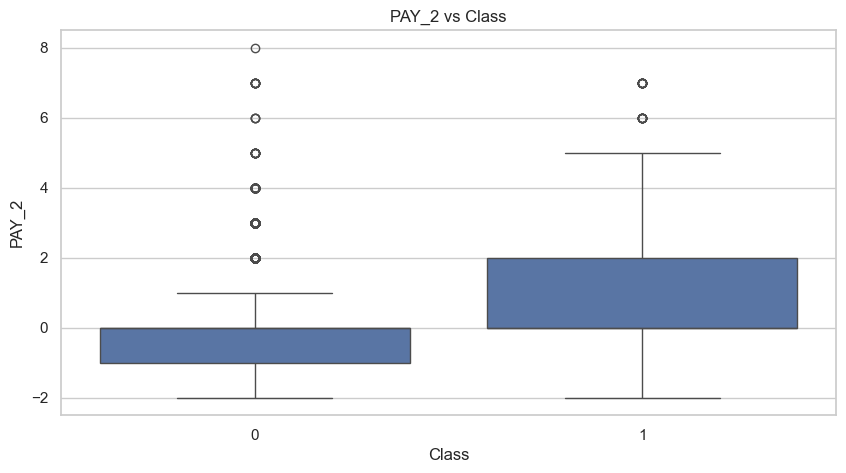

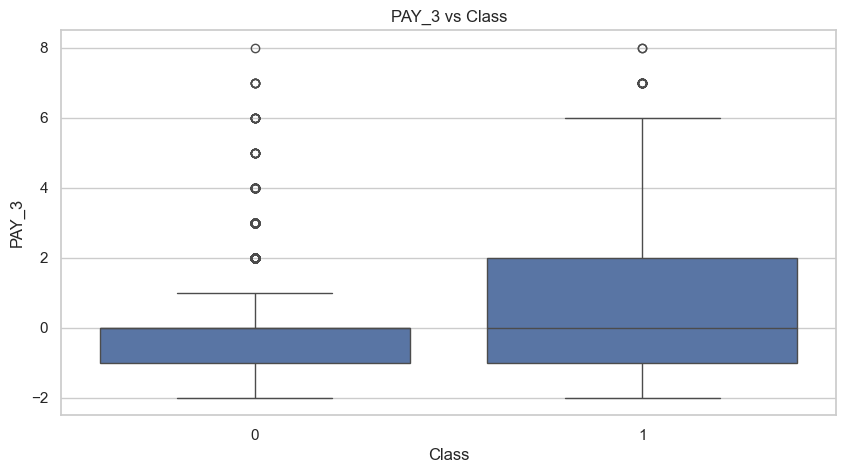

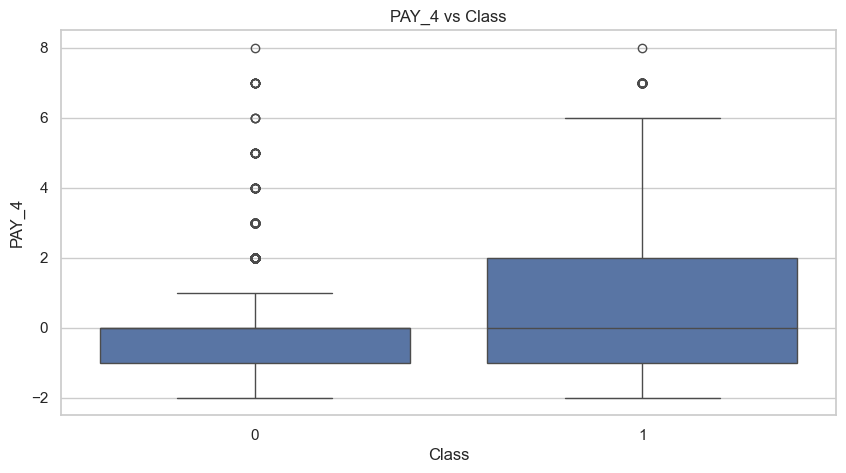

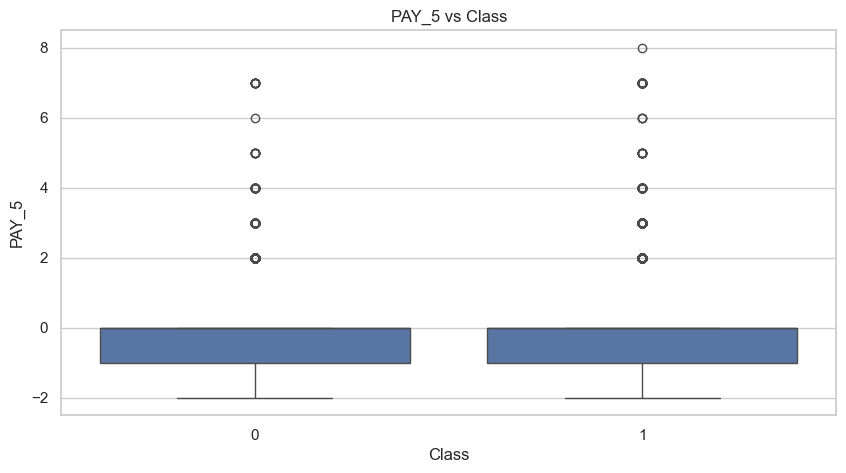

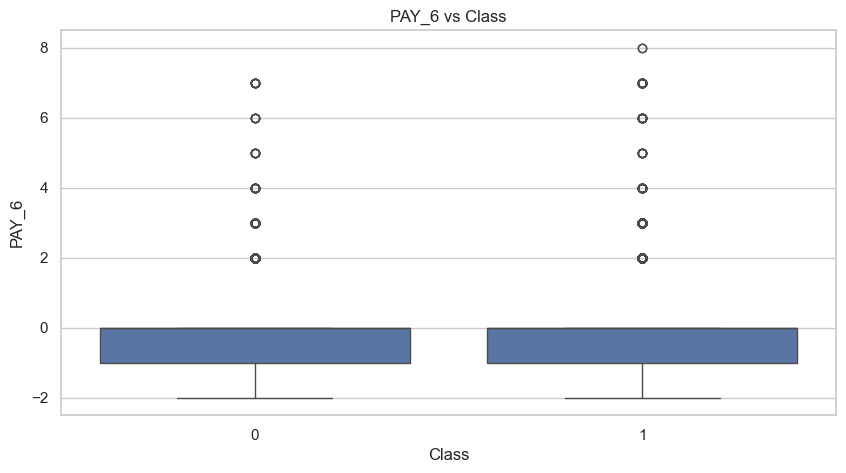

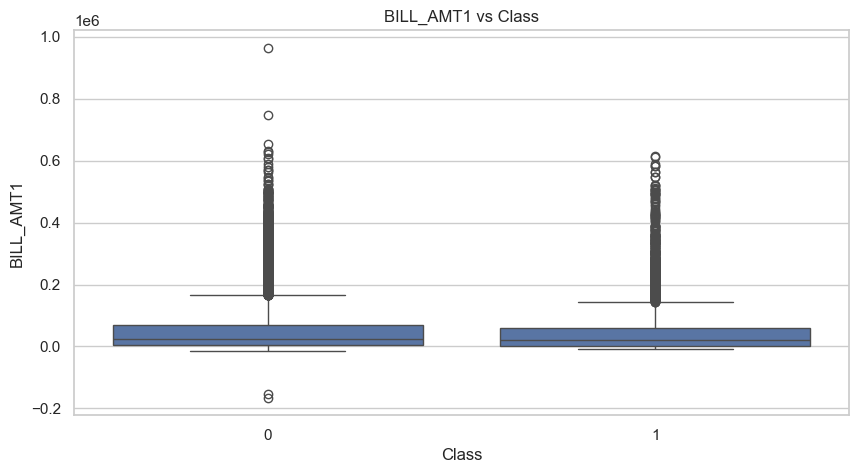

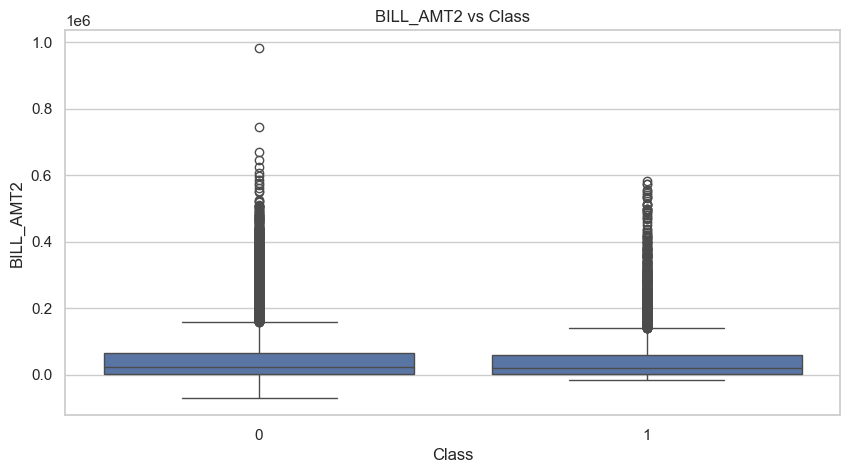

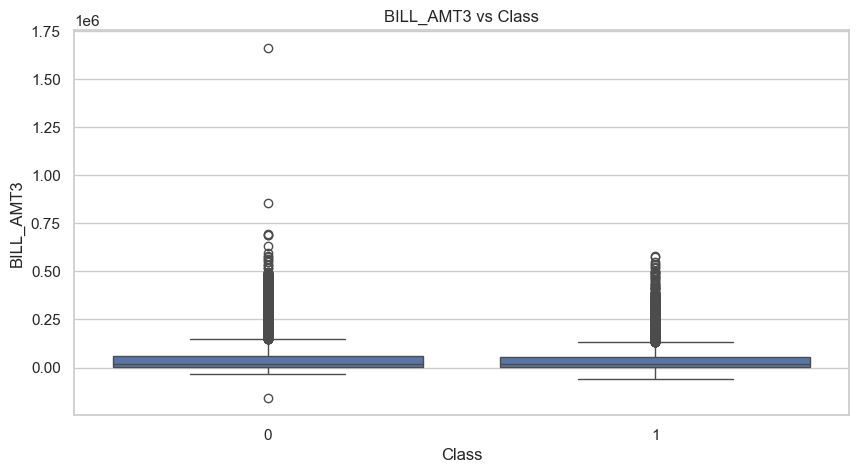

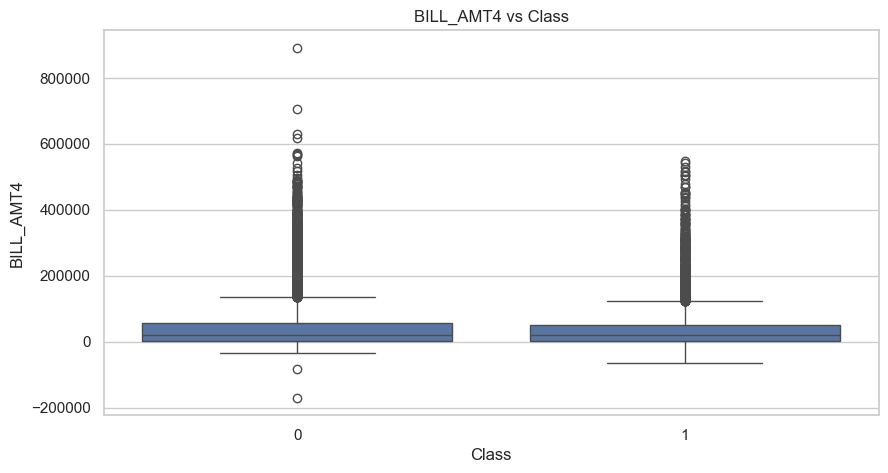

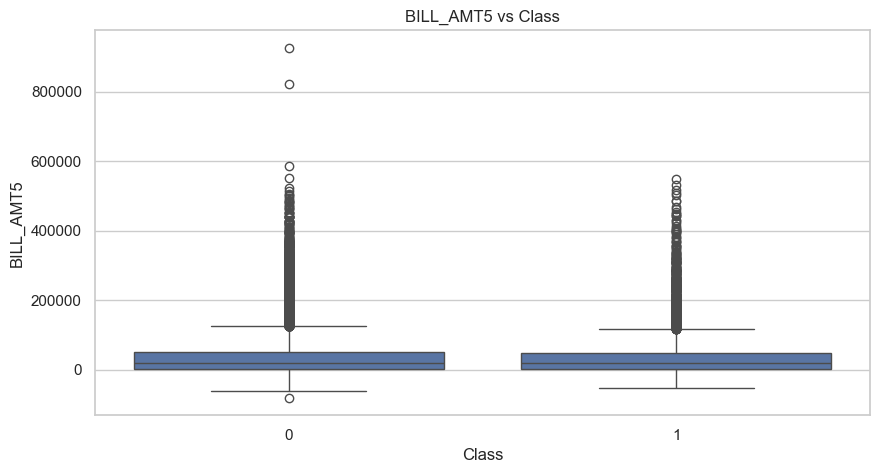

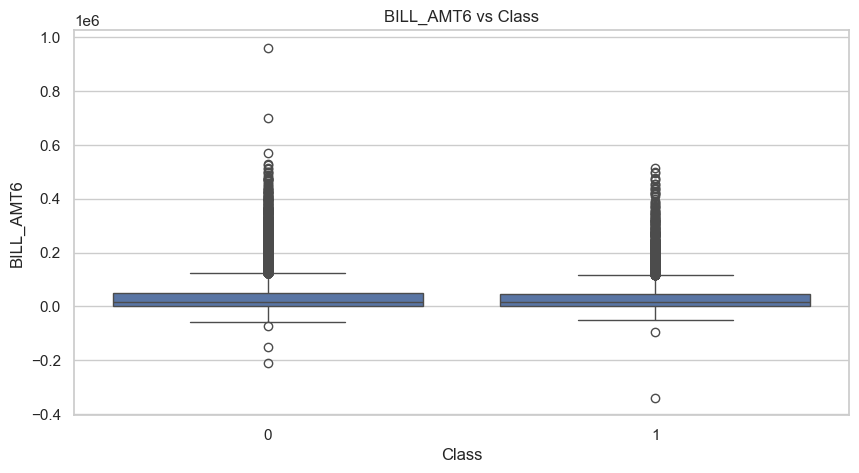

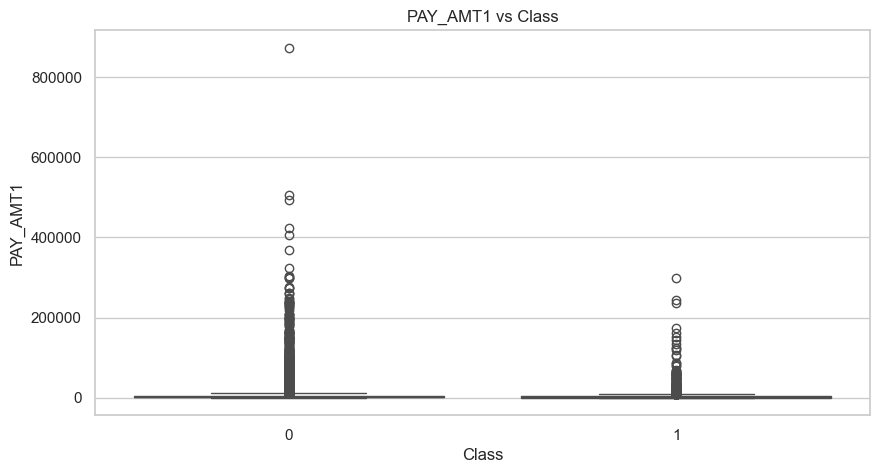

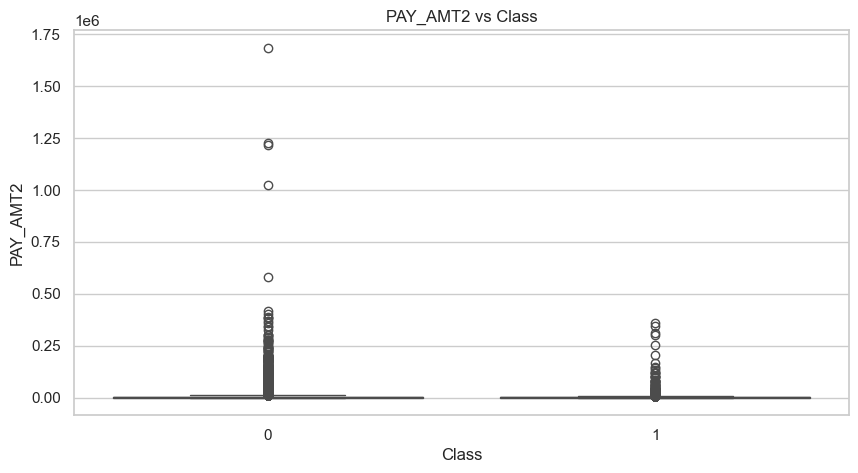

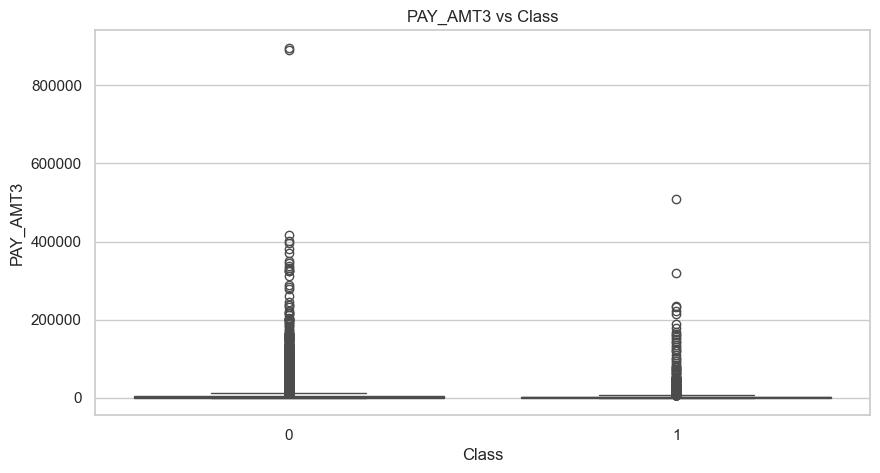

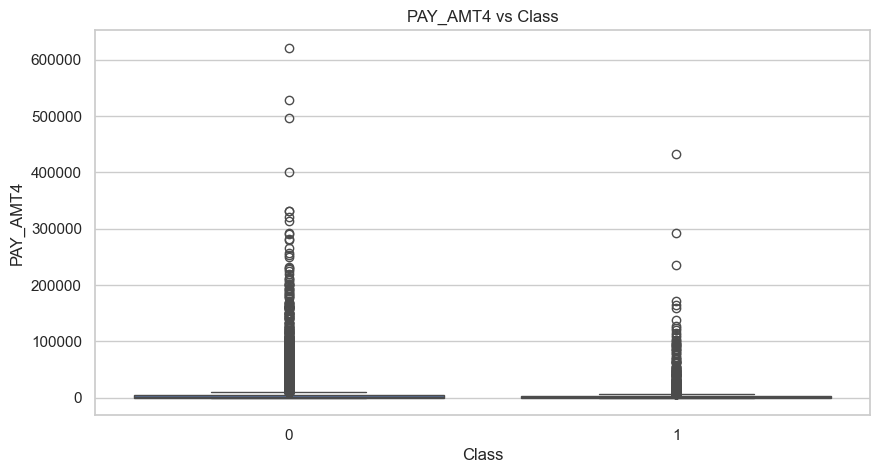

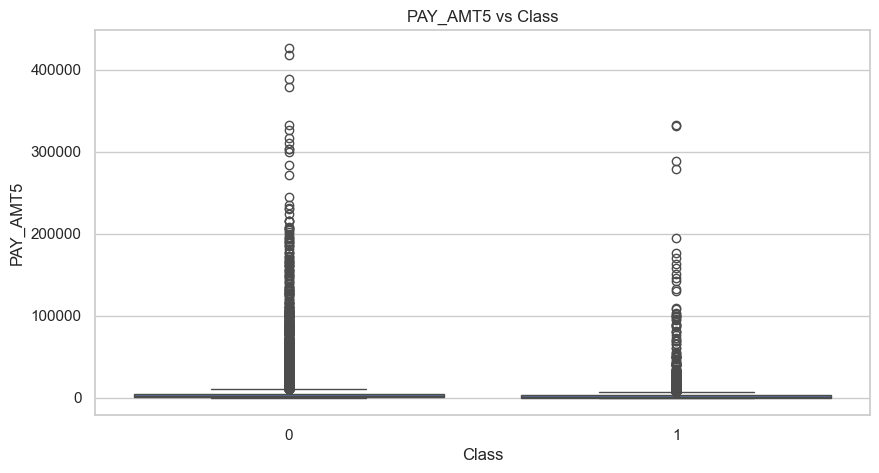

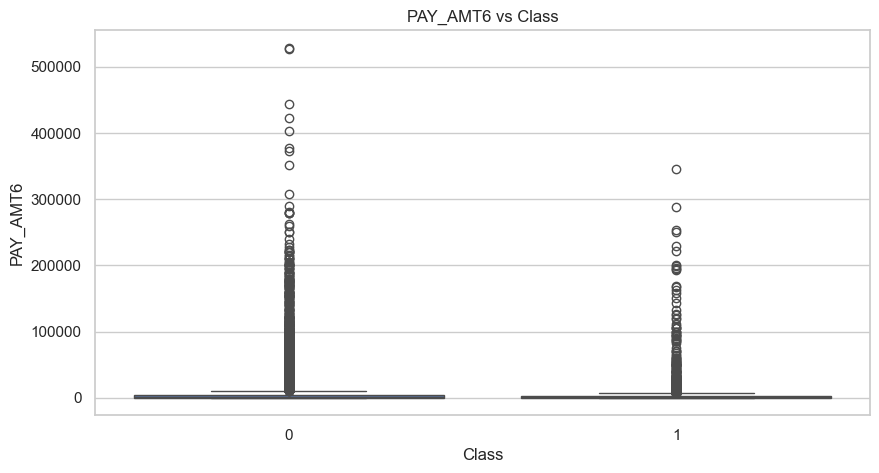

In [14]:
# Numerical vs target
plot_num_vs_target(df, num_cols, target='Class')

# 10. Correlation Analysis

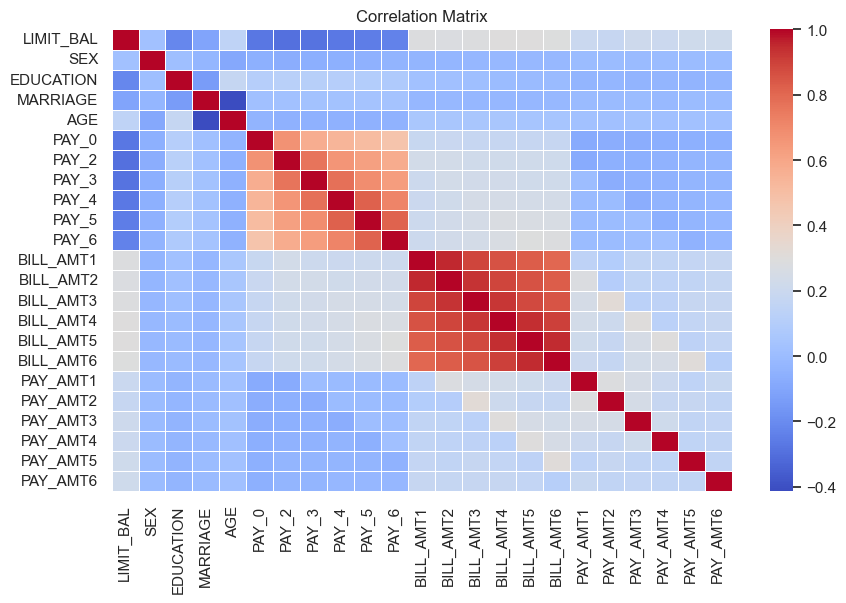

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.024755,-0.219161,-0.108139,0.144713,-0.271214,-0.296382,-0.286123,-0.267460,-0.249411,...,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
SEX,0.024755,1.000000,0.014232,-0.031389,-0.090874,-0.057643,-0.070771,-0.066096,-0.060173,-0.055064,...,-0.024563,-0.021880,-0.017005,-0.016733,-0.000242,-0.001391,-0.008597,-0.002229,-0.001667,-0.002766
EDUCATION,-0.219161,0.014232,1.000000,-0.143464,0.175061,0.105364,0.121566,0.114025,0.108793,0.097520,...,0.013002,-0.000451,-0.007567,-0.009099,-0.037456,-0.030038,-0.039943,-0.038218,-0.040358,-0.037200
MARRIAGE,-0.108139,-0.031389,-0.143464,1.000000,-0.414170,0.019917,0.024199,0.032688,0.033122,0.035629,...,-0.024909,-0.023344,-0.025393,-0.021207,-0.005979,-0.008093,-0.003541,-0.012659,-0.001205,-0.006641
AGE,0.144713,-0.090874,0.175061,-0.414170,1.000000,-0.039447,-0.050148,-0.053048,-0.049722,-0.053826,...,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
PAY_0,-0.271214,-0.057643,0.105364,0.019917,-0.039447,1.000000,0.672164,0.574245,0.538841,0.509426,...,0.179785,0.179125,0.180635,0.176980,-0.079269,-0.070101,-0.070561,-0.064005,-0.058190,-0.058673
PAY_2,-0.296382,-0.070771,0.121566,0.024199,-0.050148,0.672164,1.000000,0.766552,0.662067,0.622780,...,0.224146,0.222237,0.221348,0.219403,-0.080701,-0.058990,-0.055901,-0.046858,-0.037093,-0.036500
PAY_3,-0.286123,-0.066096,0.114025,0.032688,-0.053048,0.574245,0.766552,1.000000,0.777359,0.686775,...,0.227494,0.227202,0.225145,0.222327,0.001295,-0.066793,-0.053311,-0.046067,-0.035863,-0.035861
PAY_4,-0.267460,-0.060173,0.108793,0.033122,-0.049722,0.538841,0.662067,0.777359,1.000000,0.819835,...,0.244983,0.245917,0.242902,0.239154,-0.009362,-0.001944,-0.069235,-0.043461,-0.033590,-0.026565
PAY_5,-0.249411,-0.055064,0.097520,0.035629,-0.053826,0.509426,0.622780,0.686775,0.819835,1.000000,...,0.243335,0.271915,0.269783,0.262509,-0.006089,-0.003191,0.009062,-0.058299,-0.033337,-0.023027


In [15]:
# Correlation heatmap including target
correlation_heatmap(df, cols=num_cols, annot=False, cmap='coolwarm')

# 11. Default Rate by Demographics

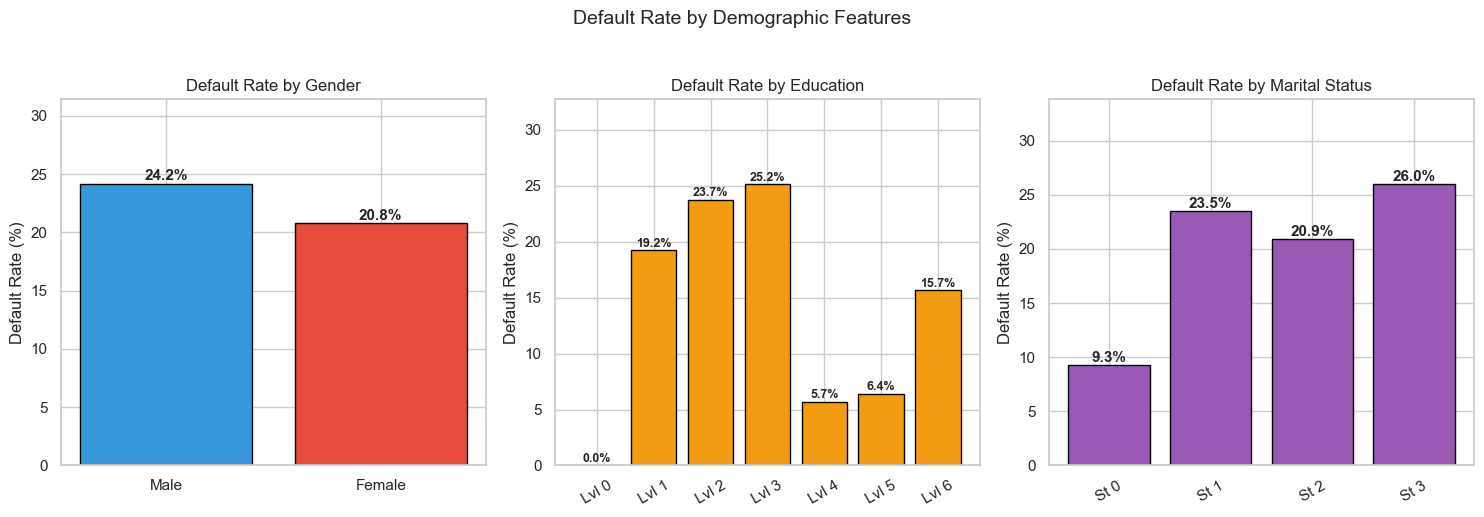


===== DEMOGRAPHIC DEFAULT RATES =====
Gender:
SEX
1    24.167227
2    20.776281
Name: Class, dtype: float64

Education:
EDUCATION
0     0.000000
1    19.234766
2    23.734854
3    25.157616
4     5.691057
5     6.428571
6    15.686275
Name: Class, dtype: float64

Marital Status:
MARRIAGE
0     9.259259
1    23.471704
2    20.928339
3    26.006192
Name: Class, dtype: float64


In [16]:
plot_default_rate_demographics(
    df,
    target_col='Class',
    save_path='../figures/default_credit_demographics.png'
)

## 12. Outlier Detection (IQR Method Example)

In [17]:
# Print outlier counts for all numerical features
print("===== OUTLIER SUMMARY (IQR) - Key Features =====")
outlier_summary(df, cols=num_cols)


===== OUTLIER SUMMARY (IQR) - Key Features =====
LIMIT_BAL: 167 outliers
SEX: 0 outliers
EDUCATION: 454 outliers
MARRIAGE: 0 outliers
AGE: 272 outliers
PAY_0: 3130 outliers
PAY_2: 4410 outliers
PAY_3: 4209 outliers
PAY_4: 3508 outliers
PAY_5: 2968 outliers
PAY_6: 3079 outliers
BILL_AMT1: 2400 outliers
BILL_AMT2: 2395 outliers
BILL_AMT3: 2469 outliers
BILL_AMT4: 2622 outliers
BILL_AMT5: 2725 outliers
BILL_AMT6: 2693 outliers
PAY_AMT1: 2745 outliers
PAY_AMT2: 2714 outliers
PAY_AMT3: 2598 outliers
PAY_AMT4: 2994 outliers
PAY_AMT5: 2945 outliers
PAY_AMT6: 2958 outliers


# 13. Missing Values

In [18]:
missing_values_report(df)

No missing values.


Series([], dtype: int64)

# 14. Key Insights

In [19]:
class_counts = df['Class'].value_counts()

print("===== KEY INSIGHTS =====")
print(f"1. Dataset size: {len(df):,} samples with {df.shape[1]} features")
print(f"2. Default rate: {df['Class'].mean()*100:.2f}%")
print(f"3. Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")
print(f"4. Average credit limit: NT${df['LIMIT_BAL'].mean():,.0f}")
print(f"5. Average age: {df['AGE'].mean():.1f} years")
print(f"6. Gender distribution: {df['SEX'].value_counts().to_dict()}")
print(f"7. All features are numerical (no categorical columns)")
print(f"8. PAY_* columns show repayment status (-2 to 8, where positive = delayed)")
print(f"9. Bill amounts are right‑skewed with many zeros")

print("\n✅ EDA Complete.")

===== KEY INSIGHTS =====
1. Dataset size: 30,000 samples with 24 features
2. Default rate: 22.12%
3. Imbalance ratio: 3.52:1
4. Average credit limit: NT$167,484
5. Average age: 35.5 years
6. Gender distribution: {2: 18112, 1: 11888}
7. All features are numerical (no categorical columns)
8. PAY_* columns show repayment status (-2 to 8, where positive = delayed)
9. Bill amounts are right‑skewed with many zeros

✅ EDA Complete.


# 15. Save EDA Cleaned Dataset

In [20]:
df.to_csv("../data/processed/default_credit_EDA_cleaned.csv", index=False)
print(f"✅ Cleaned dataset saved")
print(f"   Shape: {df.shape}")
print(f"   Class distribution:\n{df['Class'].value_counts()}")

✅ Cleaned dataset saved
   Shape: (30000, 24)
   Class distribution:
Class
0    23364
1     6636
Name: count, dtype: int64
